In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
import yfinance as yf
import seaborn as sns
import cartopy.crs as ccrs

#UCDP

In [31]:
Caminho_Tratados = "../data/tratados/"
Caminho_Imagens = "../images/"

df_conflitos = pd.read_csv(Caminho_Tratados + "Conflitos.csv", sep=",")
df_BA = pd.read_csv(Caminho_Tratados + "BA.csv", sep=",", index_col="date", parse_dates=True)
df_GD = pd.read_csv(Caminho_Tratados + "GD.csv", sep=",", index_col="date", parse_dates=True)
df_LMT = pd.read_csv(Caminho_Tratados + "LMT.csv", sep=",", index_col="date", parse_dates=True)
df_SP = yf.download("^GSPC", multi_level_index=False, start='2014-01-01', end='2017-12-30')

df_conflitos.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   location        156 non-null    str  
 1   side_a          156 non-null    str  
 2   side_a_2nd      68 non-null     str  
 3   side_b          156 non-null    str  
 4   side_b_2nd      11 non-null     str  
 5   territory_name  155 non-null    str  
 6   year            156 non-null    int64
 7   start_date      156 non-null    str  
 8   start_date2     156 non-null    str  
 9   ep_end_date     30 non-null     str  
 10  continente      156 non-null    str  
 11  location_br     156 non-null    str  
dtypes: int64(1), str(11)
memory usage: 42.1 KB


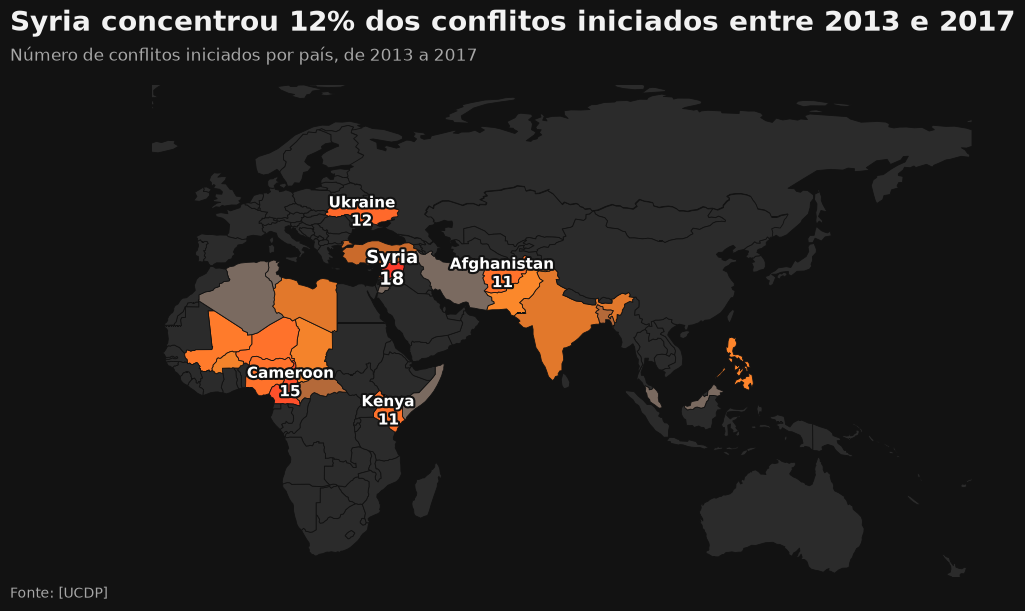

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader

FUNDO = "#121212"
CINZA_SEM_DADO = "#2B2B2B"
CINZA_TEXTO = "#A6A6A6"
TEXTO = "#F2F2F2"

FONTE = "Fonte: [UCDP]"
ANO_INI, ANO_FIM = 2013, 2017
N_ROTULOS = 5

cmap = mcolors.LinearSegmentedColormap.from_list(
    "quente", ["#7A6A60", "#C9692B", "#FF8A2B", "#FF3B2B"]
)

# --- Mapeia cada "location" (inglês, usado para casar com o shapefile) ao seu nome em português ---
nomes_br = df_conflitos.drop_duplicates("location").set_index("location")["location_br"].to_dict()

contagem = df_conflitos["location"].value_counts().to_dict()
total = sum(contagem.values())
ranking = sorted(contagem.items(), key=lambda x: x[1], reverse=True)
top_nome, top_qtd = ranking[0]
top_nome_br = nomes_br.get(top_nome, top_nome)
rotulados = dict(ranking[:N_ROTULOS])

norm = mcolors.PowerNorm(gamma=0.5, vmin=1, vmax=top_qtd)

fig = plt.figure(figsize=(12, 6), facecolor=FUNDO)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20, 180, -40, 80], crs=ccrs.PlateCarree())
ax.spines["geo"].set_visible(False)
ax.set_facecolor(FUNDO)

arquivo = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

halo = [pe.withStroke(linewidth=3, foreground=FUNDO)]
nomes_mapa = set()

for pais in shpreader.Reader(arquivo).records():
    nome = pais.attributes["ADMIN"]
    nomes_mapa.add(nome)
    quantidade = contagem.get(nome, 0)

    if quantidade > 0:
        cor = cmap(norm(quantidade))
    else:
        cor = CINZA_SEM_DADO

    ax.add_geometries(
        [pais.geometry],
        ccrs.PlateCarree(),
        facecolor=cor,
        edgecolor=FUNDO,
        linewidth=0.6
    )

    if nome in rotulados:
        ponto = pais.geometry.representative_point()
        destaque = nome == top_nome
        nome_exibido = nomes_br.get(nome, nome)
        ax.text(ponto.x, ponto.y, f"{nome_exibido}\n{quantidade}",
                transform=ccrs.PlateCarree(), ha="center", va="center",
                fontsize=13 if destaque else 11,
                fontweight="bold",
                color="white",
                path_effects=halo,
                zorder=5)

nao_encontrados = set(contagem) - nomes_mapa
if nao_encontrados:
    print("Nomes sem correspondência no mapa:", nao_encontrados)

fig.text(0.04, 0.95, f"{top_nome_br} concentrou {top_qtd / total * 100:.0f}% dos conflitos iniciados entre {ANO_INI} e {ANO_FIM}",
         fontsize=20, fontweight="bold", color=TEXTO, ha="left")
fig.text(0.04, 0.90, f"Número de conflitos iniciados por país, de {ANO_INI} a {ANO_FIM}",
         fontsize=12, color=CINZA_TEXTO, ha="left")

fig.text(0.04, 0.005, FONTE, fontsize=10, color=CINZA_TEXTO, ha="left")

fig.subplots_adjust(top=0.86, bottom=0.04, left=0.04, right=0.96)
fig.savefig(Caminho_Imagens + "mapa_conflitos.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

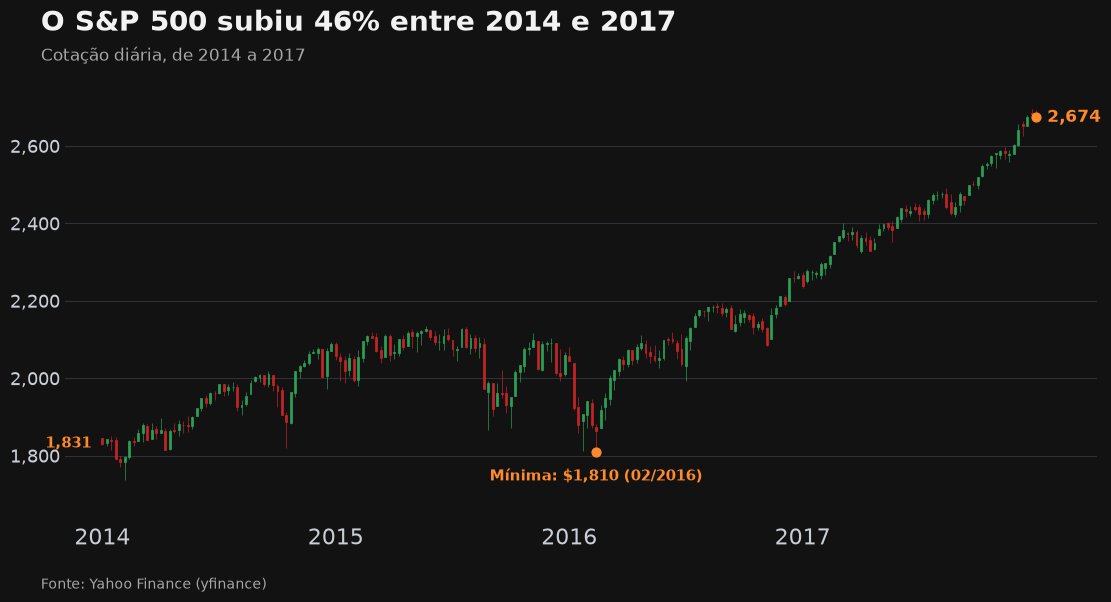

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

FUNDO = "#121212"
CINZA_TEXTO = "#A6A6A6"
EIXO = "#C8CED6"
GRADE = "#2E3238"
TEXTO = "#F2F2F2"
DESTAQUE = "#FF8A2B"
VELA_ALTA = "#2EAF5D"
VELA_BAIXA = "#D62728"

if isinstance(df_SP.columns, pd.MultiIndex):
    df_SP = df_SP.droplevel(1, axis=1)

agregacao = {
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
}
if "Volume" in df_GD.columns:
    agregacao["Volume"] = "sum"

df_SP = df_SP.resample("W").agg(agregacao).dropna()

inicio, fim = df_SP["Close"].iloc[0], df_SP["Close"].iloc[-1]
variacao = (fim / inicio - 1) * 100
verbo = "subiu" if variacao >= 0 else "caiu"
ano_ini, ano_fim = df_SP.index[0].year, df_SP.index[-1].year

df_min = df_SP.loc[df_SP.index >= "2015-01-01"]
pos_min = df_min["Low"].values.argmin()
valor_min = df_min["Low"].iloc[pos_min]
data_min = df_min.index[pos_min]
pos_min = df_SP.index.get_loc(data_min)

mc = mpf.make_marketcolors(
    up=VELA_ALTA,
    down=VELA_BAIXA,
    edge="inherit",
    wick="inherit"
)

estilo = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle="",
    facecolor=FUNDO,
    figcolor=FUNDO,
    edgecolor=FUNDO
)

fig, ax = plt.subplots(
    figsize=(12, 6),
    facecolor=FUNDO
)

mpf.plot(
    df_SP,
    type="candle",
    style=estilo,
    ax=ax,
    datetime_format="%Y",
    xrotation=0
)

# --- Posiciona um rótulo exatamente no 1º dia de cada ano ---
posicoes, rotulos = [], []
anos_vistos = set()
for i, data in enumerate(df_SP.index):
    if data.year not in anos_vistos:
        anos_vistos.add(data.year)
        posicoes.append(i)
        rotulos.append(str(data.year))

ax.set_xticks(posicoes)
ax.set_xticklabels(rotulos, rotation=0, ha="center")
# -----------------------------------------------------------------

ax.set_facecolor(FUNDO)

for lado in ["top", "right", "left", "bottom"]:
    ax.spines[lado].set_visible(False)

ax.yaxis.set_visible(True)
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.set_ylabel("")

ax.yaxis.set_major_formatter(
    lambda v, pos: f"{v:,.0f}"
)

ax.tick_params(
    axis="y",
    length=0,
    colors=EIXO,
    labelsize=13
)

ax.tick_params(
    axis="x",
    length=0,
    colors=EIXO,
    labelsize=16
)

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    color=GRADE,
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

x_ini, x_fim = 0, len(df_SP) - 1

ax.scatter(
    x_fim,
    fim,
    color=DESTAQUE,
    s=40,
    zorder=5
)

ax.annotate(
    f"{fim:,.0f}",
    (x_fim, fim),
    xytext=(8, 0),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=12,
    fontweight="bold",
    va="center"
)

ax.annotate(
    f"{inicio:,.0f}",
    (x_ini, inicio),
    xytext=(-8, 0),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=11,
    va="center",
    ha="right",
    fontweight="bold"
)

ax.scatter(
    pos_min,
    valor_min,
    color=DESTAQUE,
    s=40,
    zorder=5
)

ax.annotate(
    f"Mínima: ${valor_min:,.0f} ({data_min:%m/%Y})",
    (pos_min, valor_min),
    xytext=(0, -12),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=11,
    fontweight="bold",
    va="top",
    ha="center"
)

ymin, ymax = ax.get_ylim()

ax.set_ylim(
    ymin - (ymax - ymin) * 0.06,
    ymax
)

ax.set_xlim(
    -len(df_SP) * 0.04,
    len(df_SP) * 1.06
)

fig.text(
    0.06,
    0.95,
    f"O S&P 500 {verbo} {abs(variacao):.0f}% entre {ano_ini} e {ano_fim}",
    fontsize=20,
    fontweight="bold",
    color=TEXTO,
    ha="left"
)

fig.text(
    0.06,
    0.90,
    f"Cotação diária, de {ano_ini} a {ano_fim}",
    fontsize=12,
    color=CINZA_TEXTO,
    ha="left"
)

fig.text(
    0.06,
    0.02,
    "Fonte: Yahoo Finance (yfinance)",
    fontsize=10,
    color=CINZA_TEXTO,
    ha="left"
)

fig.subplots_adjust(
    top=0.85,
    bottom=0.13,
    left=0.08,
    right=0.94
)

fig.savefig(
    Caminho_Imagens + "SP500.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

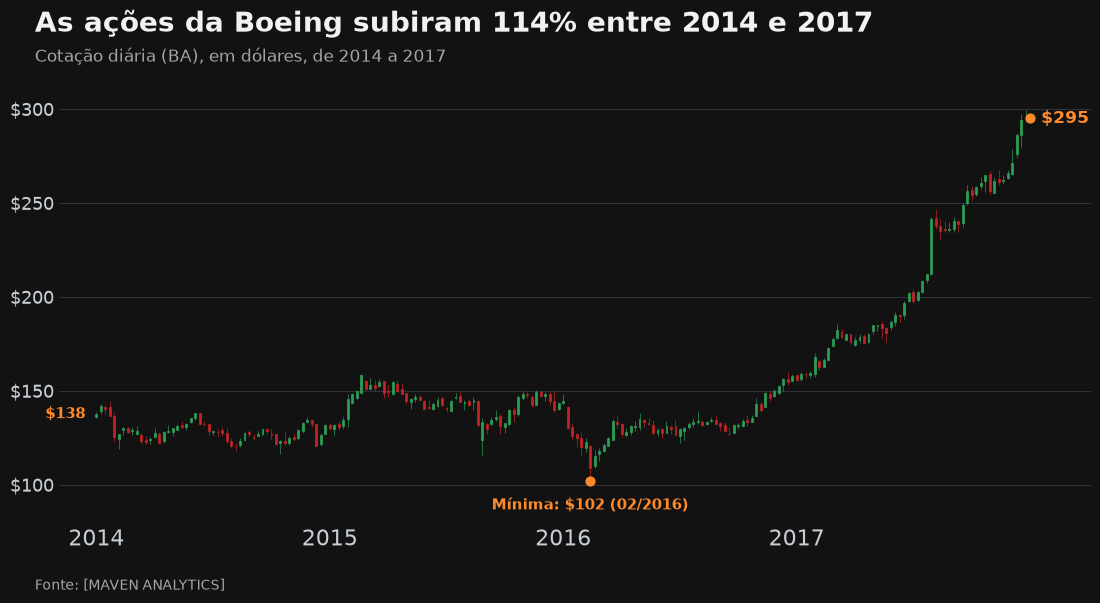

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

FUNDO = "#121212"
CINZA_TEXTO = "#A6A6A6"
EIXO = "#C8CED6"
GRADE = "#2E3238"
TEXTO = "#F2F2F2"
DESTAQUE = "#FF8A2B"
VELA_ALTA = "#2EAF5D"
VELA_BAIXA = "#D62728"

if isinstance(df_BA.columns, pd.MultiIndex):
    df_BA = df_BA.droplevel(1, axis=1)

agregacao = {
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
}
if "volume" in df_GD.columns:
    agregacao["volume"] = "sum"

df_BA = df_BA.resample("W").agg(agregacao).dropna()

inicio, fim = df_BA["close"].iloc[0], df_BA["close"].iloc[-1]
variacao = (fim / inicio - 1) * 100
verbo = "subiram" if variacao >= 0 else "caíram"
ano_ini, ano_fim = df_BA.index[0].year, df_BA.index[-1].year

pos_min = df_BA["low"].values.argmin()
valor_min = df_BA["low"].iloc[pos_min]
data_min = df_BA.index[pos_min]

mc = mpf.make_marketcolors(
    up=VELA_ALTA,
    down=VELA_BAIXA,
    edge="inherit",
    wick="inherit"
)

estilo = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle="",
    facecolor=FUNDO,
    figcolor=FUNDO,
    edgecolor=FUNDO
)

fig, ax = plt.subplots(
    figsize=(12, 6),
    facecolor=FUNDO
)

mpf.plot(
    df_BA,
    type="candle",
    style=estilo,
    ax=ax,
    datetime_format="%Y",
    xrotation=0
)

# --- Posiciona um rótulo exatamente no 1º dia de cada ano ---
posicoes, rotulos = [], []
anos_vistos = set()
for i, data in enumerate(df_BA.index):
    if data.year not in anos_vistos:
        anos_vistos.add(data.year)
        posicoes.append(i)
        rotulos.append(str(data.year))

ax.set_xticks(posicoes)
ax.set_xticklabels(rotulos, rotation=0, ha="center")
# -----------------------------------------------------------------

ax.set_facecolor(FUNDO)

for lado in ["top", "right", "left", "bottom"]:
    ax.spines[lado].set_visible(False)

ax.yaxis.set_visible(True)
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.set_ylabel("")

ax.yaxis.set_major_formatter(
    lambda v, pos: f"${v:,.0f}"
)

ax.tick_params(
    axis="y",
    length=0,
    colors=EIXO,
    labelsize=13
)

ax.tick_params(
    axis="x",
    length=0,
    colors=EIXO,
    labelsize=16
)

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    color=GRADE,
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

x_ini, x_fim = 0, len(df_BA) - 1

ax.scatter(
    x_fim,
    fim,
    color=DESTAQUE,
    s=40,
    zorder=5
)

ax.annotate(
    f"${fim:,.0f}",
    (x_fim, fim),
    xytext=(8, 0),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=12,
    fontweight="bold",
    va="center"
)

ax.annotate(
    f"${inicio:,.0f}",
    (x_ini, inicio),
    xytext=(-8, 0),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=11,
    va="center",
    ha="right",
    fontweight="bold"
)

ax.scatter(
    pos_min,
    valor_min,
    color=DESTAQUE,
    s=40,
    zorder=5
)

ax.annotate(
    f"Mínima: ${valor_min:,.0f} ({data_min:%m/%Y})",
    (pos_min, valor_min),
    xytext=(0, -12),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=11,
    fontweight="bold",
    va="top",
    ha="center"
)

ymin, ymax = ax.get_ylim()

ax.set_ylim(
    ymin - (ymax - ymin) * 0.06,
    ymax
)

ax.set_xlim(
    -len(df_BA) * 0.04,
    len(df_BA) * 1.06
)

fig.text(
    0.06,
    0.95,
    f"As ações da Boeing {verbo} {abs(variacao):.0f}% entre {ano_ini} e {ano_fim}",
    fontsize=20,
    fontweight="bold",
    color=TEXTO,
    ha="left"
)

fig.text(
    0.06,
    0.90,
    f"Cotação diária (BA), em dólares, de {ano_ini} a {ano_fim}",
    fontsize=12,
    color=CINZA_TEXTO,
    ha="left"
)

fig.text(
    0.06,
    0.02,
    "Fonte: [MAVEN ANALYTICS]",
    fontsize=10,
    color=CINZA_TEXTO,
    ha="left"
)

fig.subplots_adjust(
    top=0.85,
    bottom=0.13,
    left=0.08,
    right=0.94
)

fig.savefig(
    Caminho_Imagens + "Boeing.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

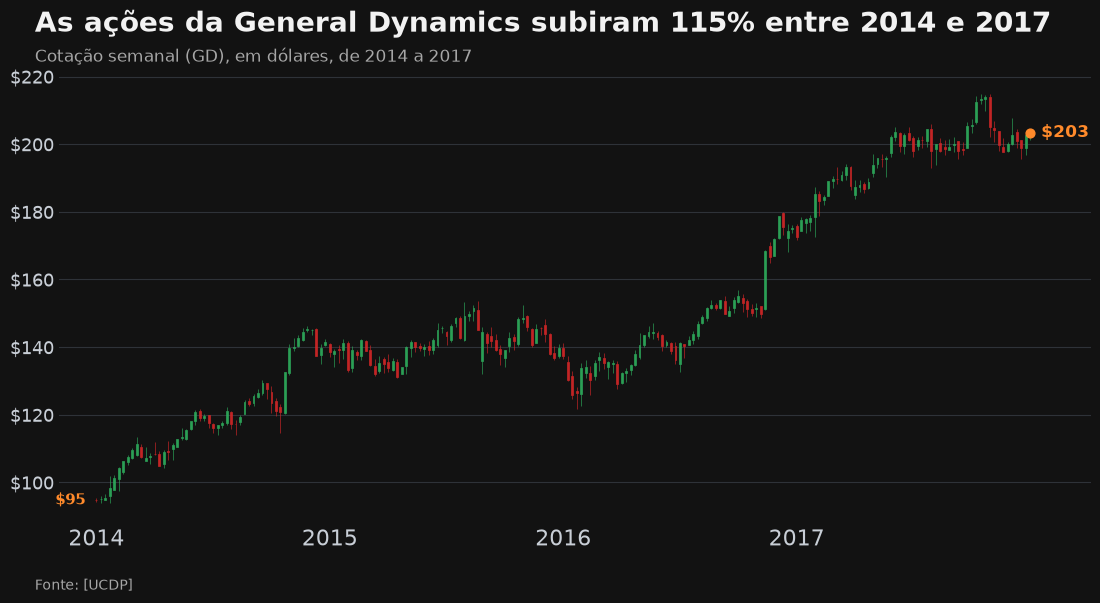

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

FUNDO = "#121212"
CINZA_TEXTO = "#A6A6A6"
EIXO = "#C8CED6"
GRADE = "#2E3238"
TEXTO = "#F2F2F2"
DESTAQUE = "#FF8A2B"
VELA_ALTA = "#2EAF5D"
VELA_BAIXA = "#D62728"

if isinstance(df_GD.columns, pd.MultiIndex):
    df_GD = df_GD.droplevel(1, axis=1)

# --- Agrupa as velas diárias em velas semanais ---
agregacao = {
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
}
if "volume" in df_GD.columns:
    agregacao["volume"] = "sum"

df_GD = df_GD.resample("W").agg(agregacao).dropna()
# ----------------------------------------------------

inicio, fim = df_GD["close"].iloc[0], df_GD["close"].iloc[-1]
variacao = (fim / inicio - 1) * 100
verbo = "subiram" if variacao >= 0 else "caíram"
ano_ini, ano_fim = df_GD.index[0].year, df_GD.index[-1].year

mc = mpf.make_marketcolors(
    up=VELA_ALTA,
    down=VELA_BAIXA,
    edge="inherit",
    wick="inherit"
)

estilo = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle="",
    facecolor=FUNDO,
    figcolor=FUNDO,
    edgecolor=FUNDO
)

fig, ax = plt.subplots(
    figsize=(12, 6),
    facecolor=FUNDO
)

mpf.plot(
    df_GD,
    type="candle",
    style=estilo,
    ax=ax,
    datetime_format="%Y",
    xrotation=0
)

# --- Posiciona um rótulo exatamente na 1ª semana de cada ano ---
posicoes, rotulos = [], []
anos_vistos = set()
for i, data in enumerate(df_GD.index):
    if data.year not in anos_vistos:
        anos_vistos.add(data.year)
        posicoes.append(i)
        rotulos.append(str(data.year))

ax.set_xticks(posicoes)
ax.set_xticklabels(rotulos, rotation=0, ha="center")
# -----------------------------------------------------------------

ax.set_facecolor(FUNDO)

for lado in ["top", "right", "left", "bottom"]:
    ax.spines[lado].set_visible(False)

ax.yaxis.set_visible(True)
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.set_ylabel("")

ax.yaxis.set_major_formatter(
    lambda v, pos: f"${v:,.0f}"
)

ax.tick_params(
    axis="y",
    length=0,
    colors=EIXO,
    labelsize=13
)

ax.tick_params(
    axis="x",
    length=0,
    colors=EIXO,
    labelsize=16
)

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    color=GRADE,
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

x_ini, x_fim = 0, len(df_GD) - 1

ax.scatter(
    x_fim,
    fim,
    color=DESTAQUE,
    s=40,
    zorder=5
)

ax.annotate(
    f"${fim:,.0f}",
    (x_fim, fim),
    xytext=(8, 0),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=12,
    fontweight="bold",
    va="center"
)

ax.annotate(
    f"${inicio:,.0f}",
    (x_ini, inicio),
    xytext=(-8, 0),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=11,
    va="center",
    ha="right",
    fontweight="bold"
)

ax.set_xlim(
    -len(df_GD) * 0.04,
    len(df_GD) * 1.06
)

fig.text(
    0.06,
    0.95,
    f"As ações da General Dynamics {verbo} {abs(variacao):.0f}% entre {ano_ini} e {ano_fim}",
    fontsize=20,
    fontweight="bold",
    color=TEXTO,
    ha="left"
)

fig.text(
    0.06,
    0.90,
    f"Cotação semanal (GD), em dólares, de {ano_ini} a {ano_fim}",
    fontsize=12,
    color=CINZA_TEXTO,
    ha="left"
)

fig.text(
    0.06,
    0.02,
    FONTE,
    fontsize=10,
    color=CINZA_TEXTO,
    ha="left"
)

fig.subplots_adjust(
    top=0.88,
    bottom=0.13,
    left=0.08,
    right=0.94
)

fig.savefig(
    Caminho_Imagens + "GD.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

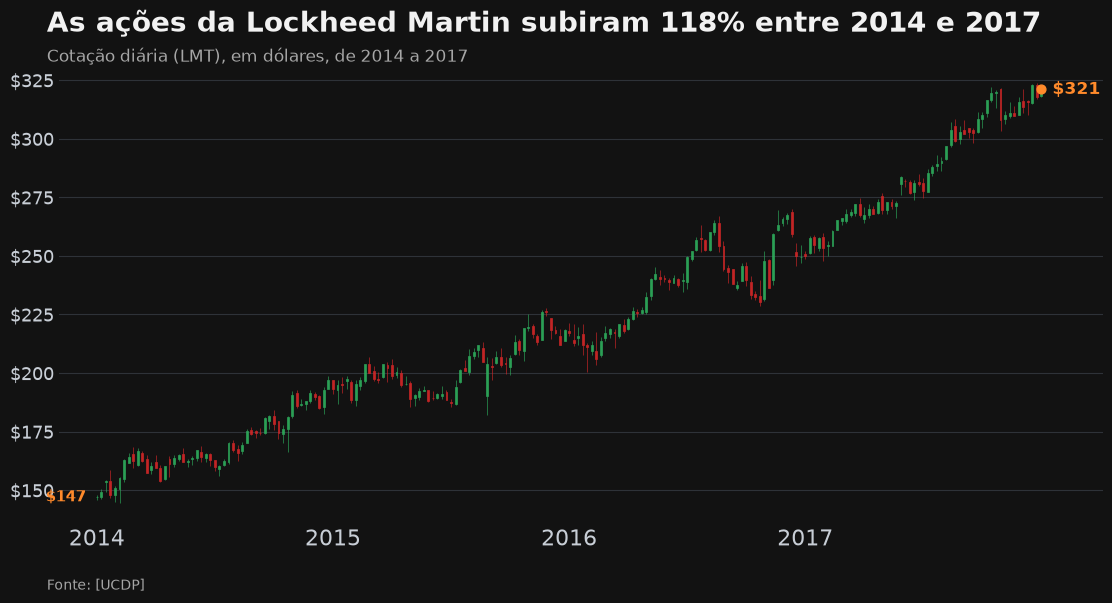

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

FUNDO = "#121212"
CINZA_TEXTO = "#A6A6A6"
EIXO = "#C8CED6"
GRADE = "#2E3238"
TEXTO = "#F2F2F2"
DESTAQUE = "#FF8A2B"
VELA_ALTA = "#2EAF5D"
VELA_BAIXA = "#D62728"

if isinstance(df_LMT.columns, pd.MultiIndex):
    df_LMT = df_LMT.droplevel(1, axis=1)

agregacao = {
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
}
if "volume" in df_GD.columns:
    agregacao["volume"] = "sum"

df_LMT = df_LMT.resample("W").agg(agregacao).dropna()

inicio, fim = df_LMT["close"].iloc[0], df_LMT["close"].iloc[-1]
variacao = (fim / inicio - 1) * 100
verbo = "subiram" if variacao >= 0 else "caíram"
ano_ini, ano_fim = df_LMT.index[0].year, df_LMT.index[-1].year

mc = mpf.make_marketcolors(
    up=VELA_ALTA,
    down=VELA_BAIXA,
    edge="inherit",
    wick="inherit"
)

estilo = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle="",
    facecolor=FUNDO,
    figcolor=FUNDO,
    edgecolor=FUNDO
)

fig, ax = plt.subplots(
    figsize=(12, 6),
    facecolor=FUNDO
)

mpf.plot(
    df_LMT,
    type="candle",
    style=estilo,
    ax=ax,
    datetime_format="%Y",
    xrotation=0
)

# --- Posiciona um rótulo exatamente no 1º dia de cada ano ---
posicoes, rotulos = [], []
anos_vistos = set()
for i, data in enumerate(df_LMT.index):
    if data.year not in anos_vistos:
        anos_vistos.add(data.year)
        posicoes.append(i)
        rotulos.append(str(data.year))

ax.set_xticks(posicoes)
ax.set_xticklabels(rotulos, rotation=0, ha="center")
# -----------------------------------------------------------------

ax.set_facecolor(FUNDO)

for lado in ["top", "right", "left", "bottom"]:
    ax.spines[lado].set_visible(False)

ax.yaxis.set_visible(True)
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.set_ylabel("")

ax.yaxis.set_major_formatter(
    lambda v, pos: f"${v:,.0f}"
)

ax.tick_params(
    axis="y",
    length=0,
    colors=EIXO,
    labelsize=13
)

ax.tick_params(
    axis="x",
    length=0,
    colors=EIXO,
    labelsize=16
)

ax.set_axisbelow(True)

ax.grid(
    axis="y",
    color=GRADE,
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

x_ini, x_fim = 0, len(df_LMT) - 1

ax.scatter(
    x_fim,
    fim,
    color=DESTAQUE,
    s=40,
    zorder=5
)

ax.annotate(
    f"${fim:,.0f}",
    (x_fim, fim),
    xytext=(8, 0),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=12,
    fontweight="bold",
    va="center"
)

ax.annotate(
    f"${inicio:,.0f}",
    (x_ini, inicio),
    xytext=(-8, 0),
    textcoords="offset points",
    color=DESTAQUE,
    fontsize=11,
    va="center",
    ha="right",
    fontweight="bold"
)

ax.set_xlim(
    -len(df_LMT) * 0.04,
    len(df_LMT) * 1.06
)

fig.text(
    0.06,
    0.95,
    f"As ações da Lockheed Martin {verbo} {abs(variacao):.0f}% entre {ano_ini} e {ano_fim}",
    fontsize=20,
    fontweight="bold",
    color=TEXTO,
    ha="left"
)

fig.text(
    0.06,
    0.90,
    f"Cotação diária (LMT), em dólares, de {ano_ini} a {ano_fim}",
    fontsize=12,
    color=CINZA_TEXTO,
    ha="left"
)

fig.text(
    0.06,
    0.02,
    FONTE,
    fontsize=10,
    color=CINZA_TEXTO,
    ha="left"
)

fig.subplots_adjust(
    top=0.9,
    bottom=0.13,
    left=0.07,
    right=0.94
)

fig.savefig(
    Caminho_Imagens + "LMT.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()